In [1]:
# this is a tutorial about Q-learning. 
# reference: https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/


In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import gym

# Explore FrozenLake-v0 

In [84]:
env = gym.make("FrozenLake-v0", desc = None, map_name = "8x8", is_slippery= False)   
# "FrozenLake8x8-v0"   for 8x8 grid world

print('action space:', env.action_space)   #  0: push left, 1: no push, 2: push right
#print('state lower limits:', env.observation_space.low)  # lower boundaries of states
#print('state higher limits:', env.observation_space.high) # higher boundaries of states
print('state tensor:', env.observation_space)      # observation space

state = env.reset()    # return an intial state: [location, velocity]

print('initial state:', state)
env.render
print(env.nA)
print(env.nS)
print(env.P[0])  
# transition probability for state 0: 
# {action: [(prob, next_state, reward, done), (...), ..., (...)],
#  action: [(prob, next_state, reward, done), (...), ..., (...)],
# ...}

action space: Discrete(4)
state tensor: Discrete(16)
initial state: 0
4
16
{0: [(1.0, 0, 0.0, False)], 1: [(1.0, 4, 0.0, False)], 2: [(1.0, 1, 0.0, False)], 3: [(1.0, 0, 0.0, False)]}


In [85]:


done = False
steps = 0
while not done:
    steps += 1
    action = 2  # always push right!
    new_state, reward, end, _= env.step(action)    # excute one step 
    env.render()  # display
    print(new_state, reward, end)
    if steps >= 5:
        break


  (Right)
SFFF
FHFH
FFFH
HFFG
1 0.0 False
  (Right)
SFFF
FHFH
FFFH
HFFG
2 0.0 False
  (Right)
SFFF
FHFH
FFFH
HFFG
3 0.0 False
  (Right)
SFFF
FHFH
FFFH
HFFG
3 0.0 False
  (Right)
SFFF
FHFH
FFFH
HFFG
3 0.0 False


# define Q table

In [10]:
# next: 1) e-greedy policy to generate episodes; 
#       2) Q table update;
#       3) decay the epsilon; 
#       4) result statistic analysis and plots

In [86]:
# Q-Learning settings
LEARNING_RATE = 0.1  #0.05
DISCOUNT = 0.99
EPISODES = 20000           # 25000 normally
SHOW_EVERY = 1000
# For statistics
STATS_EVERY = 100
ep_rewards = []
aggr_ep_rewards = {'ep': [], 'success': [], 'epsilon':[]}

# E-greedy settings
epsilon = 1  # initial value

START_EPSILON_DECAYING = 1 # decay starting point

END_EPSILON_DECAYING = EPISODES//2  # decay ending point
# floor division: the first half of episodes use linearly decayed epsilon
# the second half use the constant e following the smallest e in the first half.

epsilon_decay_step = epsilon/(END_EPSILON_DECAYING - START_EPSILON_DECAYING)
# we use e-greedy policy to generate each episode



In [87]:
q_table = np.zeros((env.observation_space.n, env.action_space.n))

for episode in range(EPISODES):
    episode_reward = 0  # initialize episode return
    discrete_state = env.reset()  # initialize state
    done = False

    if episode % SHOW_EVERY == 0:
        render = True
        print(episode)
    else:
        render = False
   
    while not done:
        # choose action
        if np.random.random() > epsilon:
            # Get greedy action from Q table
            action = np.argmax(q_table[discrete_state])
        else:
            # Get random action
            action = np.random.randint(0, env.action_space.n) # action randomly selected from: 0, 1, 2
            #action = env.action_space.sample()    # alternative way: random action
        
        # take action
        new_state, reward, done, _ = env.step(action)
        episode_reward += reward  # accumulate rewards
        
        new_discrete_state = new_state # new state in discrete
        
        # display
        if render:
            env.render()
        

        # If simulation did not end yet after last step - update Q table
        # new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q - current_q)
        
        if not done:

            # Maximum q value at new state
            max_future_q = np.max(q_table[new_discrete_state])

            # Current q value at current state and action
            current_q = q_table[discrete_state, action]

            # update equation for a new q value at current state and action: Q-learning
            new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q-current_q)



            # Update q_table at current state and action, with new q value
            q_table[discrete_state, action] = new_q



        # If goal position is achived - update q value with 0
        
        elif new_state == 15:   # env.goal_position is 0.5
            #q_table[discrete_state + (action,)] = reward
            #q_table[discrete_state + (action,)] = 0
            q_table[discrete_state, action] = 1

        discrete_state = new_discrete_state
    
    # one episode is done!
    # epislon is decayed every episode if episode number is within decaying range
    if END_EPSILON_DECAYING-2 >= episode >= START_EPSILON_DECAYING:
        epsilon -= epsilon_decay_step 
        # reduce epsilon by an amount after each episode
    
    ep_rewards.append(episode_reward)
    if not (episode+1) % STATS_EVERY:
        # the segment of episodes: ep_rewards[-STATS_EVERY:]
        # On recent STATS_EVERY=100 episodes: average, max, min reward
        average_reward = sum(ep_rewards[-STATS_EVERY:])/STATS_EVERY
        aggr_success = sum(1 for i in ep_rewards[-STATS_EVERY:] if i ==1)/STATS_EVERY
        aggr_ep_rewards['ep'].append(episode)
        aggr_ep_rewards['success'].append(aggr_success)
        aggr_ep_rewards['epsilon'].append(epsilon)
        #print(f'Episode: {episode:>5d}, average reward: {average_reward:>4.1f}, current epsilon: {epsilon:>1.4f}')
        print(f'Episode: {episode:>5d}, success rate: {aggr_success:>7.4f}, current epsilon: {epsilon:>1.4f}')


    env.close() # optional
    

0
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Up)
SFFF
FHFH
FFFH
HFFG
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Right)
SFFF
FHFH
FFFH
HFFG
Episode:    99, success rate:  0.0400, current epsilon: 0.9901
Episode:   199, success rate:  0.0300, current epsilon: 0.9801
Episode:   299, success rate:  0.0200, current epsilon: 0.9701
Episode:   399, success rate:  0.0300, current epsilon: 0.9601
Episode:   499, success rate:  0.0300, current epsilon: 0.9501
Episode:   599, success rate:  0.0500, current epsilon: 0.9401
Episode:   699, success rate:  0.0200, current epsilon: 0.9301
Episode:   799, success rate:  0.0800, current epsilon: 0.9201
Episode:   899, success rate:  0.0800, current epsilon: 0.9101
Episode:   999, success rate:  0.0500, current epsilon: 0.9001
1000
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Right)
SFFF
FHFH
FFFH
HFFG
  (Up)
SFFF
FHFH
FFFH
HFFG
Episode:  1099, success rate:  0.0400, current epsilon: 0.8901
Episode:  1199, success rate:  0.0300, current epsilon: 0.8801
Episode

Episode:  9699, success rate:  0.9300, current epsilon: 0.0300
Episode:  9799, success rate:  0.9900, current epsilon: 0.0200
Episode:  9899, success rate:  0.9700, current epsilon: 0.0100
Episode:  9999, success rate:  1.0000, current epsilon: 0.0001
10000
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Right)
SFFF
FHFH
FFFH
HFFG
  (Down)
SFFF
FHFH
FFFH
HFFG
  (Right)
SFFF
FHFH
FFFH
HFFG
  (Right)
SFFF
FHFH
FFFH
HFFG
Episode: 10099, success rate:  1.0000, current epsilon: 0.0001
Episode: 10199, success rate:  1.0000, current epsilon: 0.0001
Episode: 10299, success rate:  1.0000, current epsilon: 0.0001
Episode: 10399, success rate:  1.0000, current epsilon: 0.0001
Episode: 10499, success rate:  1.0000, current epsilon: 0.0001
Episode: 10599, success rate:  1.0000, current epsilon: 0.0001
Episode: 10699, success rate:  1.0000, current epsilon: 0.0001
Episode: 10799, success rate:  1.0000, current epsilon: 0.0001
Episode: 10899, success rate:  1.0000, current epsilon: 0.000

Episode: 19699, success rate:  1.0000, current epsilon: 0.0001
Episode: 19799, success rate:  1.0000, current epsilon: 0.0001
Episode: 19899, success rate:  1.0000, current epsilon: 0.0001
Episode: 19999, success rate:  1.0000, current epsilon: 0.0001


In [62]:
print(q_table)

[[0.87460142 0.90833241 0.87524767 0.87457796]
 [0.8790335  0.90818078 0.87876834 0.87905745]
 [0.92746379 0.88560963 0.88644945 0.88652289]
 [0.87595974 0.88151718 0.87579305 0.87594436]
 [0.90395702 0.93528599 0.90845438 0.90527201]
 [0.         0.         0.         0.        ]
 [0.93259312 0.966444   0.9421811  0.90958301]
 [0.         0.         0.         0.        ]
 [0.92090431 0.95191867 0.92904117 0.92877076]
 [0.9469821  0.95579402 0.96818744 0.94608499]
 [0.95752382 0.97575477 0.95673756 0.9524447 ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.96048211 0.97989667 0.96652997 0.96624188]
 [0.97380526 0.97460217 1.         0.97509804]
 [0.         0.         0.         0.        ]]


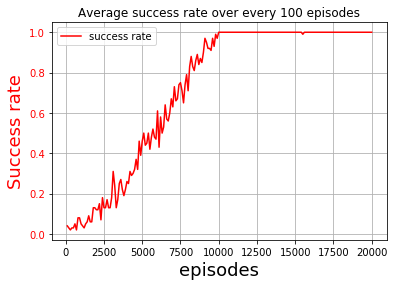

In [89]:
# Create a figure and the first axis
fig, ax1 = plt.subplots()
# Plot average rewards on the first y-axis
ax1.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['success'], label='success rate', color='red', linestyle='-')
ax1.set_xlabel('episodes', fontsize='18')  # Common x-axis label
ax1.set_ylabel('Success rate', color='red', fontsize='18')
ax1.tick_params(axis='y', labelcolor='red')

# Add a title
plt.title('Average success rate over every 100 episodes')

# Optional: Add a legend
ax1.legend(loc=2)
#ax2.legend(loc='lower right')

# Show the plot
plt.grid(True)
plt.show()